In [1]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

In [4]:
import os
print(os.getcwd())

C:\Users\Ojiugo\python_decal_sp26\Ojiugo


In [5]:
data_list = []
headers = []

for i in range(1, 6):
    filename = f"../course_assignments/homework10/M13_000{i}.fits"
    
    print("Trying:", filename)  # optional debug
    
    with fits.open(filename) as hdul:
        headers.append(hdul[0].header)
        data_list.append(hdul[0].data)

print(f"Loaded {len(data_list)} files")

Trying: ../course_assignments/homework10/M13_0001.fits
Trying: ../course_assignments/homework10/M13_0002.fits
Trying: ../course_assignments/homework10/M13_0003.fits
Trying: ../course_assignments/homework10/M13_0004.fits
Trying: ../course_assignments/homework10/M13_0005.fits
Loaded 5 files


In [6]:
print(len(data_list))

5


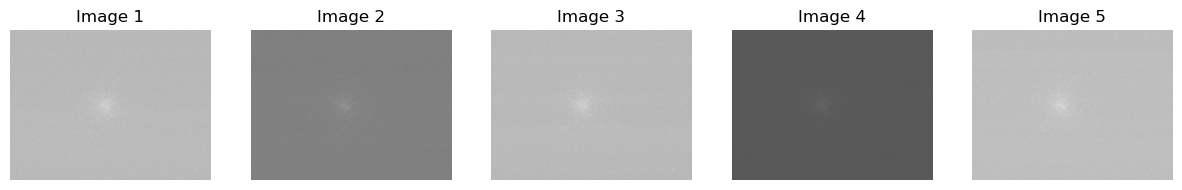

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    axes[i].imshow(data_list[i], origin="lower", cmap="gray")
    axes[i].set_title(f"Image {i+1}")
    axes[i].axis("off")

plt.show()

In [8]:
vmin = min(np.min(img) for img in data_list)
vmax = max(np.max(img) for img in data_list)

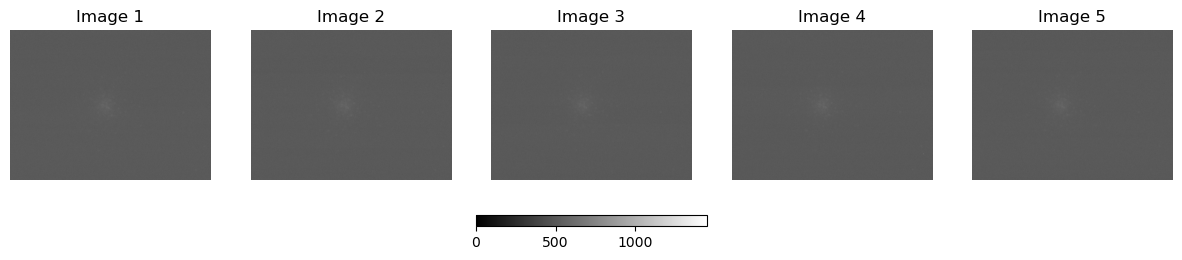

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    im = axes[i].imshow(data_list[i], origin="lower", cmap="gray", vmin=vmin, vmax=vmax)
    axes[i].set_title(f"Image {i+1}")
    axes[i].axis("off")

fig.colorbar(im, ax=axes, orientation="horizontal", fraction=0.05)

plt.show()

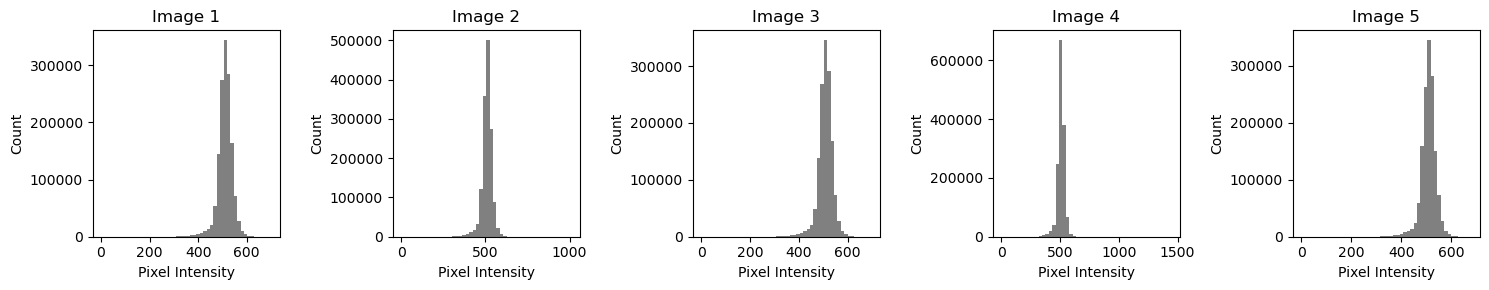

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    axes[i].hist(data_list[i].ravel(), bins=50, color='gray')
    axes[i].set_title(f"Image {i+1}")
    axes[i].set_xlabel("Pixel Intensity")
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [11]:
for i in range(5):
    img = data_list[i]
    print(f"Image {i+1}: mean = {np.mean(img):.2f}, median = {np.median(img):.2f}")

Image 1: mean = 510.47, median = 512.00
Image 2: mean = 509.75, median = 511.00
Image 3: mean = 508.05, median = 510.00
Image 4: mean = 507.91, median = 509.00
Image 5: mean = 508.79, median = 510.00


In [12]:
# Stack the 5 images into one 3D array
image_stack = np.array(data_list)

# Combine images by taking the median across axis 0
combined_image = np.median(image_stack, axis=0)

# Find median pixel intensity of combined image
combined_median = np.median(combined_image)

print(f"Median pixel intensity of combined image: {combined_median:.2f}")

Median pixel intensity of combined image: 510.00


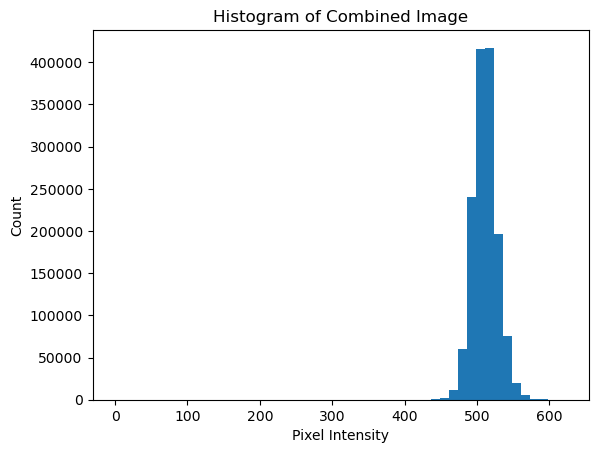

In [13]:
# Plot histogram of combined image
plt.hist(combined_image.ravel(), bins=50)
plt.xlabel("Pixel Intensity")
plt.ylabel("Count")
plt.title("Histogram of Combined Image")
plt.show()

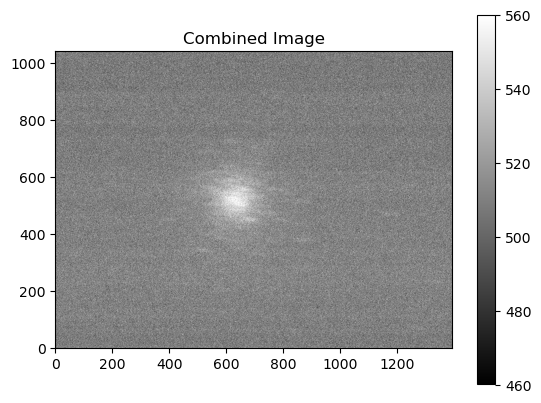

In [14]:
vmin = combined_median - 50
vmax = combined_median + 50

plt.imshow(combined_image, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)
plt.colorbar()
plt.title("Combined Image")
plt.show()